In [2]:
import zipfile
import urllib.request
# import wget 

url="https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip"
filename="pizza_steak.zip"

urllib.request.urlretrieve(url,filename)
print("done")

#unzip the file

zip_ref=zipfile.ZipFile(filename,'r')
zip_ref.extractall()   # folder (pizza_steak) created
zip_ref.close()
print("extraction done")

done
extraction done


shape: (512, 512, 3)


<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[132, 119, 110],
        [132, 119, 110],
        [130, 120, 108],
        ...,
        [ 36,  31,  35],
        [ 37,  32,  36],
        [ 37,  32,  36]],

       [[133, 120, 111],
        [133, 120, 111],
        [132, 122, 110],
        ...,
        [ 29,  27,  30],
        [ 30,  28,  31],
        [ 30,  28,  31]],

       [[134, 121, 112],
        [132, 122, 112],
        [132, 124, 111],
        ...,
        [ 24,  22,  23],
        [ 25,  23,  24],
        [ 26,  24,  25]],

       ...,

       [[136,  75,  57],
        [136,  75,  57],
        [137,  76,  58],
        ...,
        [149, 112,  86],
        [146, 108,  85],
        [145, 104,  82]],

       [[134,  73,  55],
        [134,  73,  55],
        [135,  74,  56],
        ...,
        [144, 106,  83],
        [143, 105,  84],
        [143, 102,  82]],

       [[132,  70,  55],
        [133,  71,  56],
        [134,  72,  57],
        ...,
        [140, 102,  8

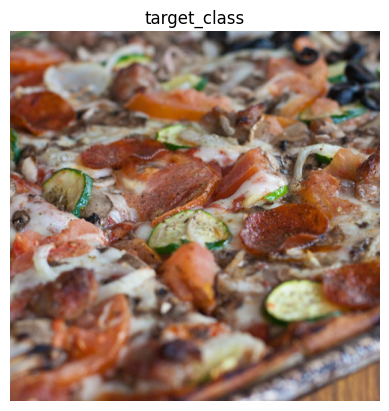

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import tensorflow as tf
import os

# function to plot random images from the directory
def rand_img(target_dir,target_class):
    target_folder=target_dir + target_class # creating a new folder with dir and classes
    random_img=random.sample(os.listdir(target_folder),1)

    img=mpimg.imread(target_folder + "/" +random_img[0]) # loads img as np.array
    plt.imshow(img)
    plt.title("target_class")
    plt.axis("off")

    print("shape:",img.shape)

    return img

img=rand_img(target_dir="pizza_steak/train/",target_class="pizza")
tf.constant(img)


In [9]:

### A Non CNN Neural Network that works with Image Data

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)

train_datagen=ImageDataGenerator(rescale=1./255)
valid_datagen=ImageDataGenerator(rescale=1./255)

train_dir=r"C:\Users\Dave Roshan\OneDrive\Desktop\CNN_MOD\pizza_steak\train"
test_dir="pizza_steak/test"


train_data=train_datagen.flow_from_directory(directory=train_dir,batch_size=32,
                                             target_size=(224,224),class_mode="binary",
                                             seed=42)

valid_data=valid_datagen.flow_from_directory(directory=test_dir,batch_size=32,
                                             target_size=(224,224),class_mode="binary",
                                             seed=42)


model_l1=tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224,224,3)),
    tf.keras.layers.Dense(100,activation="relu"),
    tf.keras.layers.Dense(100,activation="relu"),
    tf.keras.layers.Dense(100,activation="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid")
])

model_l1.compile(loss="binary_crossentropy",
                 optimizer=tf.keras.optimizers.Adam(),
                 metrics=["Accuracy"])

mod_fit=model_l1.fit(train_data,epochs=6,
                     steps_per_epoch=len(train_data),
                     validation_data=valid_data,
                     validation_steps=len(valid_data))

Found 1500 images belonging to 2 classes.


Found 500 images belonging to 2 classes.
Epoch 1/6
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - Accuracy: 0.6240 - loss: 1.7889 - val_Accuracy: 0.7120 - val_loss: 0.6880
Epoch 2/6
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - Accuracy: 0.7153 - loss: 0.8971 - val_Accuracy: 0.7660 - val_loss: 0.5217
Epoch 3/6
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - Accuracy: 0.7313 - loss: 0.6406 - val_Accuracy: 0.7520 - val_loss: 0.5037
Epoch 4/6
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - Accuracy: 0.7200 - loss: 0.5803 - val_Accuracy: 0.6920 - val_loss: 0.5921
Epoch 5/6
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - Accuracy: 0.7887 - loss: 0.4811 - val_Accuracy: 0.8040 - val_loss: 0.4155
Epoch 6/6
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - Accuracy: 0.7827 - loss: 0.4794 - val_Accuracy: 0.7920 - val_loss: 0.4429


In [ ]:

### A Non CNN Neural Network that works with Image Data

### Just 4 Neurons

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)

train_datagen=ImageDataGenerator(rescale=1./255)
valid_datagen=ImageDataGenerator(rescale=1./255)

train_dir=r"C:\Users\Dave Roshan\OneDrive\Desktop\CNN_MOD\pizza_steak\train"
test_dir="pizza_steak/test"


train_data=train_datagen.flow_from_directory(directory=train_dir,batch_size=32,
                                             target_size=(224,224),class_mode="binary",
                                             seed=42)

valid_data=valid_datagen.flow_from_directory(directory=test_dir,batch_size=32,
                                             target_size=(224,224),class_mode="binary",
                                             seed=42)


model_l1=tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224,224,3)),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid")
])

model_l1.compile(loss="binary_crossentropy",
                 optimizer=tf.keras.optimizers.Adam(),
                 metrics=["Accuracy"])

mod_fit=model_l1.fit(train_data,epochs=6,
                     steps_per_epoch=len(train_data),
                     validation_data=valid_data,
                     validation_steps=len(valid_data))

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Epoch 1/6
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - Accuracy: 0.4900 - loss: 1.9506 - val_Accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/6
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - Accuracy: 0.5000 - loss: 0.6932 - val_Accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/6
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - Accuracy: 0.5000 - loss: 0.6932 - val_Accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/6
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - Accuracy: 0.5000 - loss: 0.6932 - val_Accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/6
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - Accuracy: 0.5000 - loss: 0.6932 - val_Accuracy: 0.5000 - val_loss: 0.6932
Epoch 6/6
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - Accuracy: 0.5000 - loss: 0.6932 - val_Accuracy: 0.5000 - val_loss: 0.6932
